# Mock EEG / Neuropsychological dataset

Generate a realistic simulated dataset for EEG and neuropsychological research.
Includes age, education, P300 latency (event-related potential), and APACS scores
with controlled effect sizes and correlations.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

Tweak these values to control sample size, effect sizes, and population characteristics.
All relationships between variables are defined here.

In [ ]:
n = 100

# age
age_mean, age_sd = 60, 5

# education
edu_values = [5, 8, 13, 16, 18, 22]
edu_p = [.10, .21, .34, .12, .15 , .08]

# P300 latency ~ age
P300_mean, P300_sd = 330, 25
P300_age_r = 0.3                # correlation(age, P300_latency)

# APACS ~ age + education + P300 (standardized beta weights)
apacs_mean, apacs_sd = 0.75, 0.05
apacs_beta_age = -0.10
apacs_beta_edu = 0.10
apacs_beta_P300 = -0.15
apacs_r2 = 0.25                 # total variance explained by predictors

## Randomness

Each variable uses an independent random number generator with a different seed.
Using the same seed for all would create spurious correlations, since every
variable would draw from the identical pseudo-random sequence.

In [20]:
seed = 42

rng_age = np.random.default_rng(seed)
rng_edu = np.random.default_rng(seed+1)
rng_P300 = np.random.default_rng(seed+2)
rng_apacs = np.random.default_rng(seed+3)


## Simulation

### Age

Defined as a normal distribution with `age_mean` and `age_sd`

In [21]:
float_age = rng_age.normal(loc=age_mean, scale=age_sd, size=n)
age = np.round(float_age).astype(int)

### Education

Randomly sampled from the possible `edu_values` with probabilities `edu_p`.

Education is independent of age.

In [22]:
education = rng_edu.choice(edu_values, size=n, p=edu_p)

### P300 latency

P300 latency is modeled as a linear function of age plus independent noise.

Formula: `P300 = intercept + slope · age + noise`

- **Slope** (ms/year): additional milliseconds per year of age
- **Intercept** (ms): predicted P300 latency at age 0 (mathematical construct, no physiological meaning)
- **Noise**: random variation independent of age, scaled to achieve the desired correlation

In [23]:
P300_slope = P300_age_r * P300_sd / age_sd
P300_intercept = P300_mean - P300_slope * age_mean

P300_noise = rng_P300.normal(scale=P300_sd * np.sqrt(1-P300_age_r**2), size=n)

P300_effect = P300_intercept + P300_slope * age

P300_latency = P300_effect + P300_noise


### APACS

APACS is modeled using standardized regression coefficients (beta weights).

The predictors (age, education, P300) are converted to z-scores, then combined
with the beta weights. The resulting linear predictor is scaled to explain a
controlled proportion of variance (`apacs_r2`), and independent noise fills the
remaining variance.

In [24]:

# APACS: linear predictor from standardized betas, then add noise for desired R2
age_std = (age - np.mean(age)) / np.std(age, ddof=1)
edu_std = (education - np.mean(education)) / np.std(education, ddof=1)
P300_std = (P300_latency - np.mean(P300_latency)) / np.std(P300_latency, ddof=1)

# Systematic effect (standardized scale)
APACS_effect = (
    apacs_beta_age * age_std
    + apacs_beta_edu * edu_std
    + apacs_beta_P300 * P300_std
)

# Scale linear predictor to have variance = R2
APACS_effect_scaled = APACS_effect / np.std(APACS_effect, ddof=1) * np.sqrt(apacs_r2)

# Residual noise (fills remaining variance to 1.0)
APACS_noise = rng_apacs.normal(scale=np.sqrt(1 - apacs_r2), size=n)

# Total APACS values
APACS_zscore = APACS_effect_scaled + APACS_noise
APACS_tot = apacs_mean + apacs_sd * APACS_zscore

## Plots

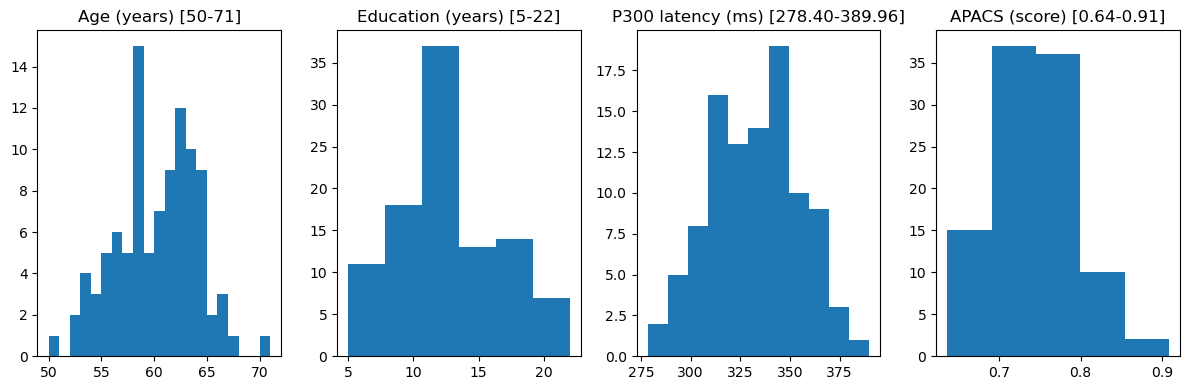

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(12,4))

axes[0].hist(age, bins=(max(age)-min(age)))
axes[0].set_title(f"Age (years) [{min(age)}-{max(age)}]")
axes[1].hist(education, bins=len(edu_values))
axes[1].set_title(f"Education (years) [{min(education)}-{max(education)}]")
axes[2].hist(P300_latency, bins=(int((max(P300_latency)-min(P300_latency))/10)))
axes[2].set_title(f"P300 latency (ms) [{min(P300_latency):.2f}-{max(P300_latency):.2f}]")
axes[3].hist(APACS_tot, bins=(int((max(APACS_tot)-min(APACS_tot))/0.05)))
axes[3].set_title(f"APACS (score) [{min(APACS_tot):.2f}-{max(APACS_tot):.2f}]")


plt.tight_layout()
plt.show()

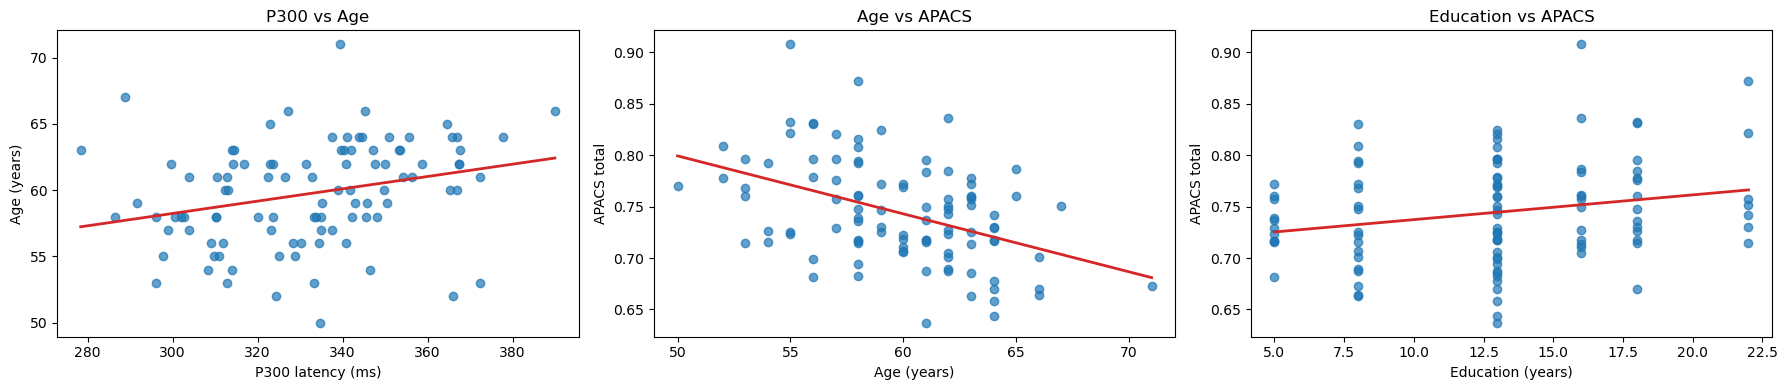

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# axes[0].scatter(P300_latency, age, alpha=0.7)
# axes[0].set_xlabel("P300 latency (ms)")
# axes[0].set_ylabel("Age (years)")
# axes[0].set_title("P300 vs Age")


# fit and plot regression lines
for ax, x, y, xlabel, ylabel, title in [
    (axes[0], P300_latency, age, "P300 latency (ms)", "Age (years)", "P300 vs Age"),
    (axes[1], age, APACS_tot, "Age (years)", "APACS total", "Age vs APACS"),
    (axes[2], education, APACS_tot, "Education (years)", "APACS total", "Education vs APACS"),
]:
    ax.scatter(x, y, alpha=0.7)
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="C3", lw=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Save dataset

Save the simulated data to a plain-text file for downstream analyses.

In [ ]:
dat = np.column_stack([age, education, P300_latency, APACS_tot])
header = "age,education,P300_latency,APACS_tot"
np.savetxt(
    "dataset_1.csv",
    dat,
    fmt=["%d", "%d", "%.6f", "%.6f"],
    delimiter=",",
    header=header,
    comments="",
)

print("dataset_1.txt")